# TELCO CHURN — LOGIT

# What we do in this notebook:
# 1) Load + understand the data (target distribution, basic checks)
# 2) Clean + encode + train/test split + scaling
# 3) Baseline Logistic Regression (sklearn) + evaluation
# 4) ROC curve + AUC (main result plot)
# 5) Odds ratios (interpretability)
# 6) L1 (Lasso-style) Logistic Regression + comparison

In [13]:
import sys
print(sys.executable)

/home/sebog/miniconda3/envs/env1/bin/python


In [14]:
# IMPORTS
# We use:
# - pandas & numpy for data handling
# - matplotlib for plots
# - sklearn for preprocessing, modeling, and evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (confusion_matrix,accuracy_score,precision_score, recall_score, roc_curve, roc_auc_score)

In [15]:
# LOAD DATA
# Load the CSV into a DataFrame and preview the first rows.

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# QUICK DATA UNDERSTANDING
# Check dataset size, data types, and churn class distribution.
# Since this is classification, knowing class balance is important.

print("Shape:", df.shape)
print("\nData types:")
df.info()

print("\nChurn distribution:")
print(df["Churn"].value_counts())

Shape: (7043, 21)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBi

In [17]:
# CLEANING: FIX TotalCharges
# TotalCharges is stored as text in this dataset.
# Convert it to numeric. Any invalid values become NaN, then we drop those rows.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nMissing values after converting TotalCharges:")
print(df.isnull().sum())

df = df.dropna()
print("\nShape after dropping NaNs:", df.shape)


Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Shape after dropping NaNs: (7032, 21)


In [18]:
# DEFINE TARGET (y) AND FEATURES (X)
# Logistic regression needs a binary numeric target:
# - No churn -> 0
# - Churn -> 1
# customerID is just an identifier, so we remove it.

y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(["Churn", "customerID"], axis=1)

In [19]:
# ENCODE CATEGORICAL VARIABLES (ONE-HOT)
# Convert categorical variables into 0/1 dummy columns so the model can use them.
# drop_first=True avoids the dummy variable trap (To get perfect multicollinearity).

X = pd.get_dummies(X, drop_first=True)
print("X shape after encoding:", X.shape)

X shape after encoding: (7032, 30)


In [20]:
# TRAIN / TEST SPLIT
# Keep a test set untouched for evaluation (generalization).
# We use 70% for training and 30% for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (4922, 30) Test shape: (2110, 30)


In [21]:
# SCALE NUMERIC FEATURES
# Logistic regression is more stable when numeric features are on similar scales.
# We scale only the numeric columns (not the 0/1 dummy columns).

X_train2 = X_train.copy()
X_test2 = X_test.copy()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train2[num_cols] = scaler.fit_transform(X_train2[num_cols])
X_test2[num_cols] = scaler.transform(X_test2[num_cols])

In [22]:
# BASELINE LOGISTIC REGRESSION (SKLEARN)
# Train the baseline logistic regression model.

logit = LogisticRegression(max_iter=2000)
logit.fit(X_train2, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [23]:
# PREDICT CLASSES + PROBABILITIES
# predict() uses the default cutoff 0.5
# predict_proba() gives probabilities for ROC/AUC.

y_pred = logit.predict(X_test2)
y_prob = logit.predict_proba(X_test2)[:, 1]

In [24]:
# EVALUATION: CONFUSION MATRIX + METRICS (cutoff = 0.5)
# Confusion matrix is the main evaluation tool in classification.
# Metrics:
# - Accuracy: overall correctness
# - Precision: how many predicted churners were truly churn
# - Recall: how many real churners we caught

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Confusion Matrix:
 [[1378  171]
 [ 261  300]]

Accuracy : 0.795260663507109
Precision: 0.6369426751592356
Recall   : 0.5347593582887701


AUC: 0.839216606884552


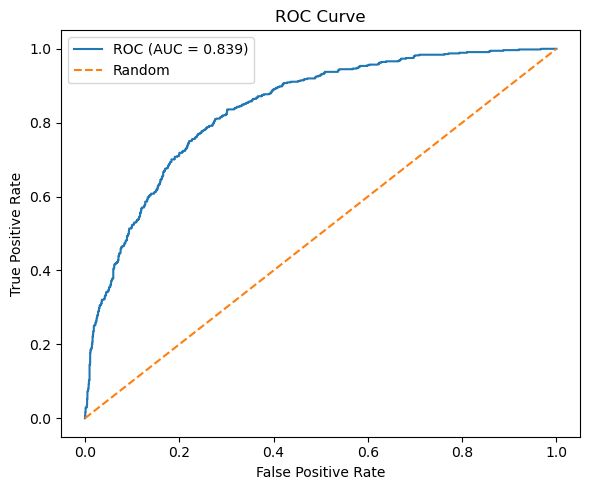

In [25]:
# ROC CURVE + AUC (MAIN RESULT PLOT)
# ROC shows model performance across thresholds.
# AUC summarizes discrimination (0.5 = random, closer to 1 = better).

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ODDS RATIOS (INTERPRETABILITY)
# Logistic regression coefficients are in log-odds.
# We convert them to odds ratios using exp(beta):
# - OR > 1 increases churn risk
# - OR < 1 reduces churn risk (protective)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logit.coef_[0]
})

coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

print("\nTop risk drivers (largest OR):")
display(coef_df.sort_values("Odds_Ratio", ascending=False).head(10))

print("\nTop protective factors (smallest OR):")
display(coef_df.sort_values("Odds_Ratio", ascending=True).head(10))


Top risk drivers (largest OR):


,Feature,Coefficient,Odds_Ratio
10,InternetService_Fiber optic,0.988077,2.686064
3,TotalCharges,0.684633,1.983044
23,StreamingMovies_Yes,0.284752,1.329432
21,StreamingTV_Yes,0.284503,1.329101
9,MultipleLines_Yes,0.225999,1.253575
0,SeniorCitizen,0.225789,1.253312
28,PaymentMethod_Electronic check,0.208314,1.231600
26,PaperlessBilling_Yes,0.208276,1.231554
5,Partner_Yes,0.131258,1.140262
17,DeviceProtection_Yes,-0.011115,0.988947



Top protective factors (smallest OR):


,Feature,Coefficient,Odds_Ratio
1,tenure,-1.445821,0.235553
25,Contract_Two year,-1.362914,0.255914
24,Contract_One year,-0.799520,0.449545
7,PhoneService_Yes,-0.454565,0.634724
13,OnlineSecurity_Yes,-0.372133,0.689263
19,TechSupport_Yes,-0.344141,0.708829
6,Dependents_Yes,-0.247532,0.780725
2,MonthlyCharges,-0.212366,0.808668
27,PaymentMethod_Credit card (automatic),-0.159967,0.852172
18,TechSupport_No internet service,-0.135659,0.873140


In [27]:
# L1 (LASSO-STYLE) LOGISTIC REGRESSION + COMPARISON
# L1 regularization can shrink weaker coefficients toward zero,
# helping with feature selection / stability.

logit_lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=2000
)

logit_lasso.fit(X_train2, y_train)

# Evaluate L1 model using the same test set
y_pred_lasso = logit_lasso.predict(X_test2)

acc_lasso = accuracy_score(y_test, y_pred_lasso)
prec_lasso = precision_score(y_test, y_pred_lasso)
rec_lasso = recall_score(y_test, y_pred_lasso)

print("\nL1 (Lasso) Metrics (cutoff=0.5):")
print("Accuracy :", acc_lasso)
print("Precision:", prec_lasso)
print("Recall   :", rec_lasso)


L1 (Lasso) Metrics (cutoff=0.5):
Accuracy : 0.7966824644549763
Precision: 0.6404255319148936
Recall   : 0.5365418894830659


In [28]:
# LASSO FEATURE INSPECTION (NON-ZERO COEFFICIENTS)
# See which predictors survive L1 regularization.
# Non-zero coefficients are the features kept by the L1 model.

lasso_selected = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logit_lasso.coef_[0]
})

lasso_selected = lasso_selected[lasso_selected["Coefficient"] != 0].copy()
lasso_selected["Odds_Ratio"] = np.exp(lasso_selected["Coefficient"])

print("Number of features kept by L1:", lasso_selected.shape[0])

print("\nL1: Top risk drivers (largest OR):")
display(lasso_selected.sort_values("Odds_Ratio", ascending=False).head(10))

print("\nL1: Top protective factors (smallest OR):")
display(lasso_selected.sort_values("Odds_Ratio", ascending=True).head(10))

Number of features kept by L1: 29

L1: Top risk drivers (largest OR):


,Feature,Coefficient,Odds_Ratio
3,TotalCharges,0.685467,1.984698
10,InternetService_Fiber optic,0.454563,1.575484
2,MonthlyCharges,0.438958,1.551090
0,SeniorCitizen,0.220181,1.246303
28,PaymentMethod_Electronic check,0.205968,1.228714
26,PaperlessBilling_Yes,0.204225,1.226575
5,Partner_Yes,0.120589,1.128161
9,MultipleLines_Yes,0.110647,1.117000
21,StreamingTV_Yes,0.064843,1.066992
23,StreamingMovies_Yes,0.063347,1.065396



L1: Top protective factors (smallest OR):


,Feature,Coefficient,Odds_Ratio
1,tenure,-1.440639,0.236776
25,Contract_Two year,-1.393182,0.248284
7,PhoneService_Yes,-0.834183,0.434229
24,Contract_One year,-0.811877,0.444024
13,OnlineSecurity_Yes,-0.472350,0.623535
19,TechSupport_Yes,-0.445135,0.640738
18,TechSupport_No internet service,-0.366990,0.692817
6,Dependents_Yes,-0.238961,0.787445
15,OnlineBackup_Yes,-0.168722,0.844744
27,PaymentMethod_Credit card (automatic),-0.152463,0.858591


# FINAL CONCLUSION

- AUC ≈ 0.839 shows strong ability to separate churners vs non-churners.
- Accuracy ≈ 0.795 with default cutoff = 0.5.
- Key churn drivers are mainly pricing/service variables (OR > 1).
- Key protective factors include tenure and longer contracts (OR < 1).
- L1 regularization keeps similar performance and confirms stability of the main drivers.